# Training, Validation, and the Bias–Variance Tradeoff

## Training, Validation, and Testing 

### Implementing the Split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing(as_frame=True)
X_housing = housing.data
y_housing = housing.target

# ── Three-way split: 60% train / 20% validation / 20% test ────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_housing, y_housing,
    test_size=0.40, random_state=RANDOM_SEED
)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50, random_state=RANDOM_SEED
)

print(f"Training set   : {X_tr.shape[0]:,} rows  ({X_tr.shape[0]/len(X_housing):.0%})")
print(f"Validation set : {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(X_housing):.0%})")
print(f"Test set       : {X_te.shape[0]:,} rows  ({X_te.shape[0]/len(X_housing):.0%})")

Training set   : 12,384 rows  (60%)
Validation set : 4,128 rows  (20%)
Test set       : 4,128 rows  (20%)


### Visualising the Split

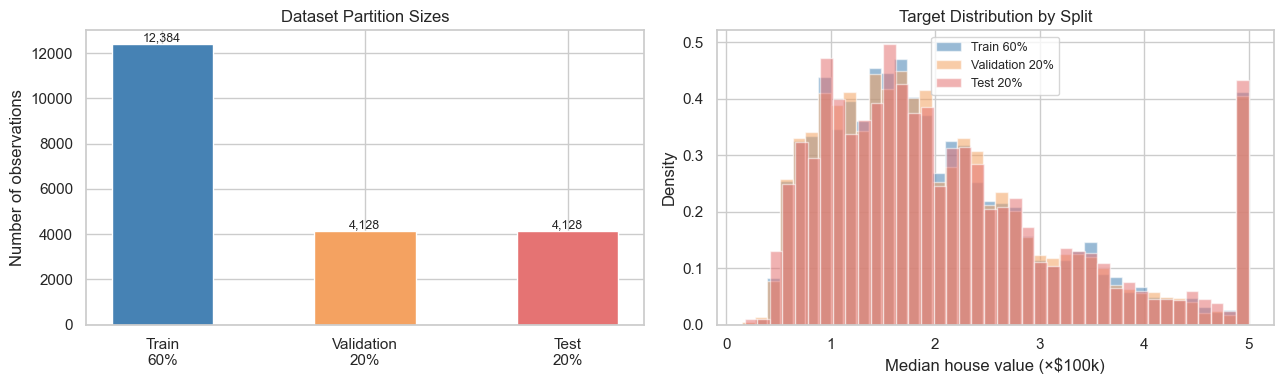

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: split proportions
sizes  = [X_tr.shape[0], X_val.shape[0], X_te.shape[0]]
labels = ["Train\n60%", "Validation\n20%", "Test\n20%"]
colors = ["steelblue", "#F4A261", "#E57373"]
axes[0].bar(labels, sizes, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Dataset Partition Sizes")
axes[0].set_ylabel("Number of observations")
for i, v in enumerate(sizes):
    axes[0].text(i, v + 150, f"{v:,}", ha="center", fontsize=9)

# Panel 2: target distribution across splits
for arr, label, color in zip([y_tr, y_val, y_te], labels, colors):
    axes[1].hist(arr, bins=40, alpha=0.55, density=True,
                 label=label.replace("\n", " "), color=color)
axes[1].set_title("Target Distribution by Split")
axes[1].set_xlabel("Median house value (×$100k)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "ch09_splits.png", dpi=150, bbox_inches="tight")
plt.show()

## The Bias-Variance Tradeoff

### Demonstrating the Tradeoff

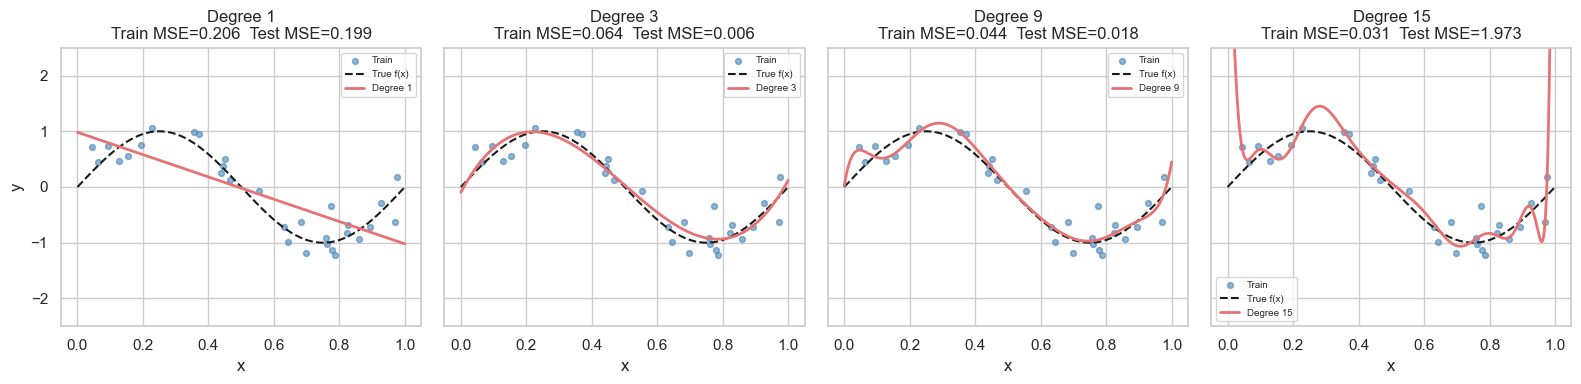

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# ── Synthetic data: y = sin(2πx) + noise ──────────────────────────────────
n_train, n_test = 30, 500
x_train = rng.uniform(0, 1, n_train)
x_test  = np.linspace(0, 1, n_test)
y_train = np.sin(2 * np.pi * x_train) + rng.normal(0, 0.3, n_train)
y_test  = np.sin(2 * np.pi * x_test)   # noiseless true function

degrees = [1, 3, 9, 15]
train_mses, test_mses = [], []

fig, axes = plt.subplots(1, len(degrees), figsize=(16, 4), sharey=True)

for ax, deg in zip(axes, degrees):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("lr",   LinearRegression())
    ])
    pipe.fit(x_train.reshape(-1, 1), y_train)

    y_pred_tr = pipe.predict(x_train.reshape(-1, 1))
    y_pred_te = pipe.predict(x_test.reshape(-1, 1))

    tr_mse = mean_squared_error(y_train, y_pred_tr)
    te_mse = mean_squared_error(y_test,  y_pred_te)
    train_mses.append(tr_mse)
    test_mses.append(te_mse)

    ax.scatter(x_train, y_train, s=18, color="steelblue", alpha=0.6, label="Train")
    ax.plot(x_test, y_test, "k--", lw=1.5, label="True f(x)")
    ax.plot(x_test, y_pred_te, color="#E57373", lw=2, label=f"Degree {deg}")
    ax.set_title(f"Degree {deg}\nTrain MSE={tr_mse:.3f}  Test MSE={te_mse:.3f}")
    ax.set_xlabel("x")
    if ax == axes[0]:
        ax.set_ylabel("y")
    ax.legend(fontsize=7)
    ax.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.savefig(FIGURES / "ch09_bvt_curves.png", dpi=150, bbox_inches="tight")
plt.show()

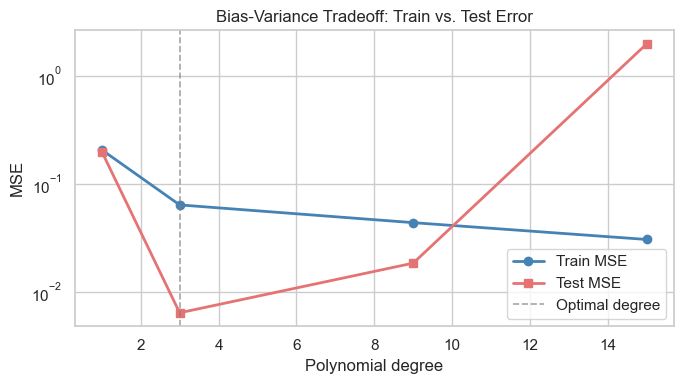

Degree  |  Train MSE  |  Test MSE
--------------------------------------
   1    |   0.2062    |  0.1988
   3    |   0.0638    |  0.0064
   9    |   0.0438    |  0.0185
  15    |   0.0306    |  1.9726


In [4]:
# ── Training vs. test MSE as a function of degree ─────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(degrees, train_mses, "o-", color="steelblue", lw=2, label="Train MSE")
plt.plot(degrees, test_mses,  "s-", color="#E57373",   lw=2, label="Test MSE")
plt.axvline(3, color="gray", lw=1.2, linestyle="--", alpha=0.7, label="Optimal degree")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Bias-Variance Tradeoff: Train vs. Test Error")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.savefig(FIGURES / "ch09_bvt_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

print("Degree  |  Train MSE  |  Test MSE")
print("-" * 38)
for d, tr, te in zip(degrees, train_mses, test_mses):
    print(f"  {d:2d}    |   {tr:.4f}    |  {te:.4f}")